In [17]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [18]:
class AgentState(TypedDict):
    number1: int
    operation1: str
    number2: int
    number3: int
    operation2: str
    result1: int
    result2: int

In [19]:
def adder1(state:AgentState)->AgentState:
    """This node adds the 2 numbers"""
    state['result1'] = state['number1'] + state['number2']
    return state
def substractor1(state:AgentState)->AgentState:
    """This node substracts the 2 numbers"""
    state['result1'] = state['number1'] - state['number2']
    return state
def adder2(state:AgentState)->AgentState:
    """This node adds the 2 numbers"""
    state['result2'] = state['result1'] + state['number3']
    return state
def substractor2(state:AgentState)->AgentState:
    """This node substracts the 2 numbers"""
    state['result2'] = state['result1'] - state['number3']
    return state
def decide_next_node1(state:AgentState)->str:
    """This node will select the next node of the graph"""
    if state["operation1"] == '+':
        return "addition"
    elif state["operation1"] == '-':
        return "substraction"
    
def decide_next_node2(state:AgentState)->str:
    """This node will select the next node of the graph"""
    if state["operation2"] == '+':
        return "addition"
    elif state["operation2"] == '-':
        return "substraction"

In [20]:
graph = StateGraph(AgentState)
graph.add_node('add_node1', adder1)
graph.add_node('substract_node1', substractor1)
graph.add_node('add_node2', adder2)
graph.add_node('substract_node2', substractor2)
graph.add_node('router1', lambda state:state)
graph.add_node('router2', lambda state:state)

graph.add_edge(START, "router1")
graph.add_conditional_edges('router1', decide_next_node1, {"addition": "add_node1", "substraction": "substract_node1"})
graph.add_edge("add_node1", "router2")
graph.add_edge("substract_node1", "router2")
graph.add_conditional_edges('router2', decide_next_node2, {"addition": "add_node2", "substraction": "substract_node2"})
graph.add_edge("add_node2", END)
graph.add_edge("substract_node2", END)

app = graph.compile()

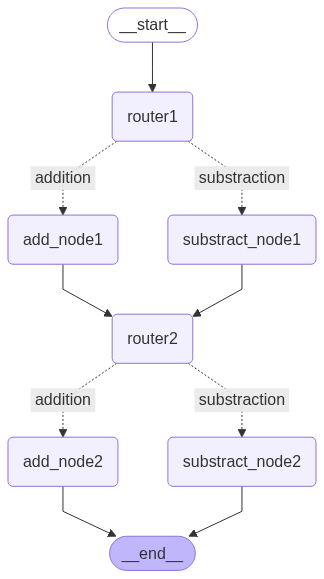

In [21]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [22]:
print(app.invoke({"number1": 3, "number2": 7, "operation1": '+', "number3": 3,  "operation2": '-'})["result2"])

7
